In [1]:
import folium
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from skgstat import Variogram
import geopandas as gpd
from shapely.geometry import Point
import statsmodels.api as sm
import ast
from shapely.ops import unary_union


Lectura y limpieza de datos

1. se leen los datos y se transforman en geodataframe añadiendo finromación sobre el barrio en CABA
2. Se borran los datos pertenecientes a barrios con menos de 5 datos
3. Se añade información sobre la cantidad de ambientes, pasando strings a nueros
4. Se añade la columna de area por metro cuadrado "area_m2", transformando los datos de string a numericos. Se borran los datos sin información de area x metro cuadradp
5. Se añade la columna expensas transformando string a numerico. Si no hay información de expensas, se asume que el valor es 0.
6. Se borran los datos con precio de alquiler menor a 100000 pesos

In [2]:
# df_alquiler = pd.read_csv("storage/data/arg_alquiler_data_1.csv")
# #df_alquiler['id'] = df_alquiler['id'].apply(lambda x: int(x))
# df_alquiler['id'] = (
#     df_alquiler['url']
#     .str.extract(r'--(\d+)$')
#     .astype('Int64')   # permite NA si alguna url está mal
# )

# df_alquiler = df_alquiler.drop(columns=[df_alquiler.columns[0]])
# df_alquiler.columns
# df_alquiler.info()
# df_alquiler.to_csv("storage/data/arg_alquiler_data.csv",  index=False)

# df_venta = pd.read_csv("storage/data/arg_venta_data_1.csv")
# #df_venta['id'] = df_venta['id'].apply(lambda x: int(x))
# df_venta['id'] = (
#     df_venta['url']
#     .str.extract(r'--(\d+)$')
#     .astype('Int64')   # permite NA si alguna url está mal
# )
# df_venta.info()

# df_alquiler.to_csv("storage/data/arg_venta_data.csv", index=False)



In [3]:
df = pd.read_csv("storage/data/arg_alquiler_data.csv")


In [4]:
sum(df['id'].value_counts()>1)

126

Feature engeneering

<Axes: >

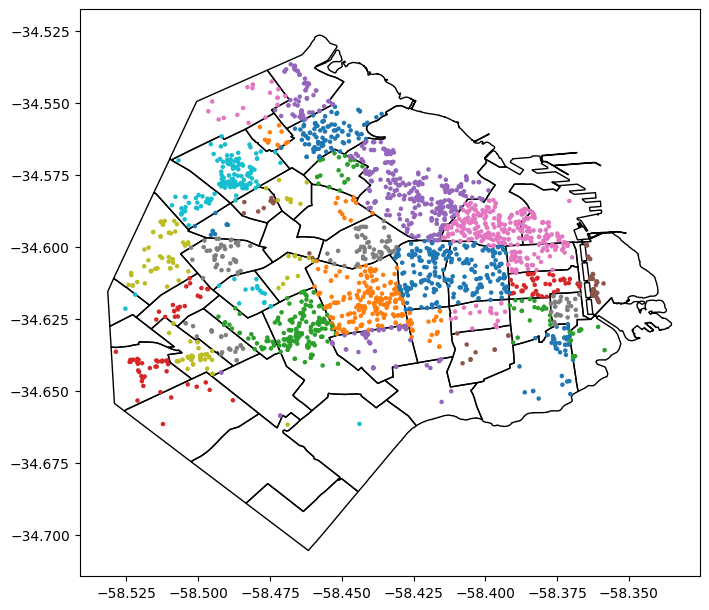

In [5]:


# Barrios
barrios = gpd.read_file("barrios.geojson")


caba_polygon = unary_union(barrios.geometry)


# Puntos
gdf_puntos = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitud, df.latitud),
    crs="EPSG:4326"
)

# Unificar CRS
barrios = barrios.to_crs(gdf_puntos.crs)
gdf = gpd.sjoin(
    gdf_puntos,
    barrios,
    how="left",
    predicate="within"
)


gdf_deptos = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitud, df.latitud),
    crs="EPSG:4326"
)

gdf = gpd.sjoin(
    gdf_deptos,
    barrios[['nombre', 'comuna', 'geometry']],
    how='left',
    predicate='within'
)
gdf= gdf.rename(columns={"nombre": "barrio"})

fig, ax = plt.subplots(figsize=(8, 8))
barrios.plot(ax=ax, edgecolor="black", facecolor="none")

gdf.plot(
    ax=ax,
    column='barrio',
    markersize=5,
    legend=False
)



In [6]:
# ─────────────────────────────
# 1. Filtrar barrios con >= 5 obs
# ─────────────────────────────
gdf = gdf[
    gdf.groupby('barrio')['barrio'].transform('size') >= 5
]

# ─────────────────────────────
# 2. Filtros de validez RECORDAR CAMBAR AMBIENTES!!!
# ─────────────────────────────
gdf = gdf[gdf['valido_hasta'].isna()]
gdf = gdf[gdf['precio'].notna()]
gdf = gdf[gdf['area_m2_total'].notna()]
gdf = gdf[gdf['ambientes'].notna()]

# ─────────────────────────────
# 3. Imputaciones simples
# ─────────────────────────────
gdf['expensas'] = gdf['expensas'].fillna(0)
gdf['banos'] = gdf['banos'].fillna(1)
gdf['cocheras'] = gdf['cocheras'].fillna(0)
gdf['area_m2_descubierta'] = gdf['area_m2_descubierta'].fillna(0)
# ─────────────────────────────
# 4. Antigüedad: media por barrio
# ─────────────────────────────
gdf['antiguedad'] = gdf['antiguedad'].fillna(
    gdf.groupby('barrio')['antiguedad'].transform('mean')
)
#En caso de que quede alguno con NA por que en un barrio hay solo un dato y este dato es NA
gdf['antiguedad'] = gdf['antiguedad'].fillna(gdf['antiguedad'].mode().iloc[0])
# ─────────────────────────────
# 5. Estado: valor más frecuente por (barrio, antiguedad)
# ─────────────────────────────
gdf['antiguedad_cat'] = gdf['antiguedad'].round().astype('Int64')

estado_moda = (
    gdf
    .dropna(subset=['estado'])
    .groupby(['barrio', 'antiguedad_cat'])['estado']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
)

# Imputar solo donde falta
mask = gdf['estado'].isna()

gdf.loc[mask, 'estado'] = (
    gdf.loc[mask]
    .set_index(['barrio', 'antiguedad_cat'])
    .index
    .map(estado_moda)
)
# hay un solo dato con ese año de antiguedad
gdf['estado'] = gdf['estado'].fillna(gdf['estado'].mode().iloc[0])

# Y ahora lo transformamos int 
orden_estado = {
    'Excelente': 5,
    "Muy Bueno": 4,
    'Bueno': 3,
    'Regular': 2,
    'A Refaccionar': 1
}
gdf["estado_num"] = gdf["estado"].map(orden_estado)


In [7]:
df_dolar = pd.read_csv("storage/data/dolar_hoy.csv")

dolar_oficial_venta = (
    df_dolar.loc[df_dolar['tipo_dolar'] == 'oficial', 'valor']
    .iloc[0]
)


mask_usd = gdf['moneda'] == "USD"

gdf.loc[mask_usd, 'precio'] = (
    gdf.loc[mask_usd, 'precio'] * dolar_oficial_venta
)


# añadimos el log del precio 
gdf['log_precio'] = np.log(gdf['precio'])

EDA

Hipotesis: El precio depende de la superficie (en m^2) y de la cantidad de ambientes, pero esta relación es igual en todo el mapa?
Por ejemplo, podría ser que si comparamos un departamento con x m^2 y 3 ambientes y vemos cuanto cambia el precio al añadir 1 ambiente más, la diferencia d eprecio sea mayor en palermo que en caballito, por lo que existe una dependencia espacial en la relación subyacente (quizá en palermo no es tan importante tener muchos ambientes y en caballito si) 

Analisis: Graficar la dependencia entre precio en USD y superficie en m^2 para cada cantidad de ambientes en cada barrio
Si vemos que las pendientes de las curvas para cada cantidad de ambientes cambia en los distintos barrios, estamos evidenciando una dependencia espacial en la relación.


In [8]:
densidad_naive = (
    gdf
    .groupby('barrio')
    .size()
    .sort_values(ascending=False)
)

densidad_naive.head()


barrio
Palermo          145
Caballito         92
Recoleta          81
Flores            68
Villa Urquiza     64
dtype: int64

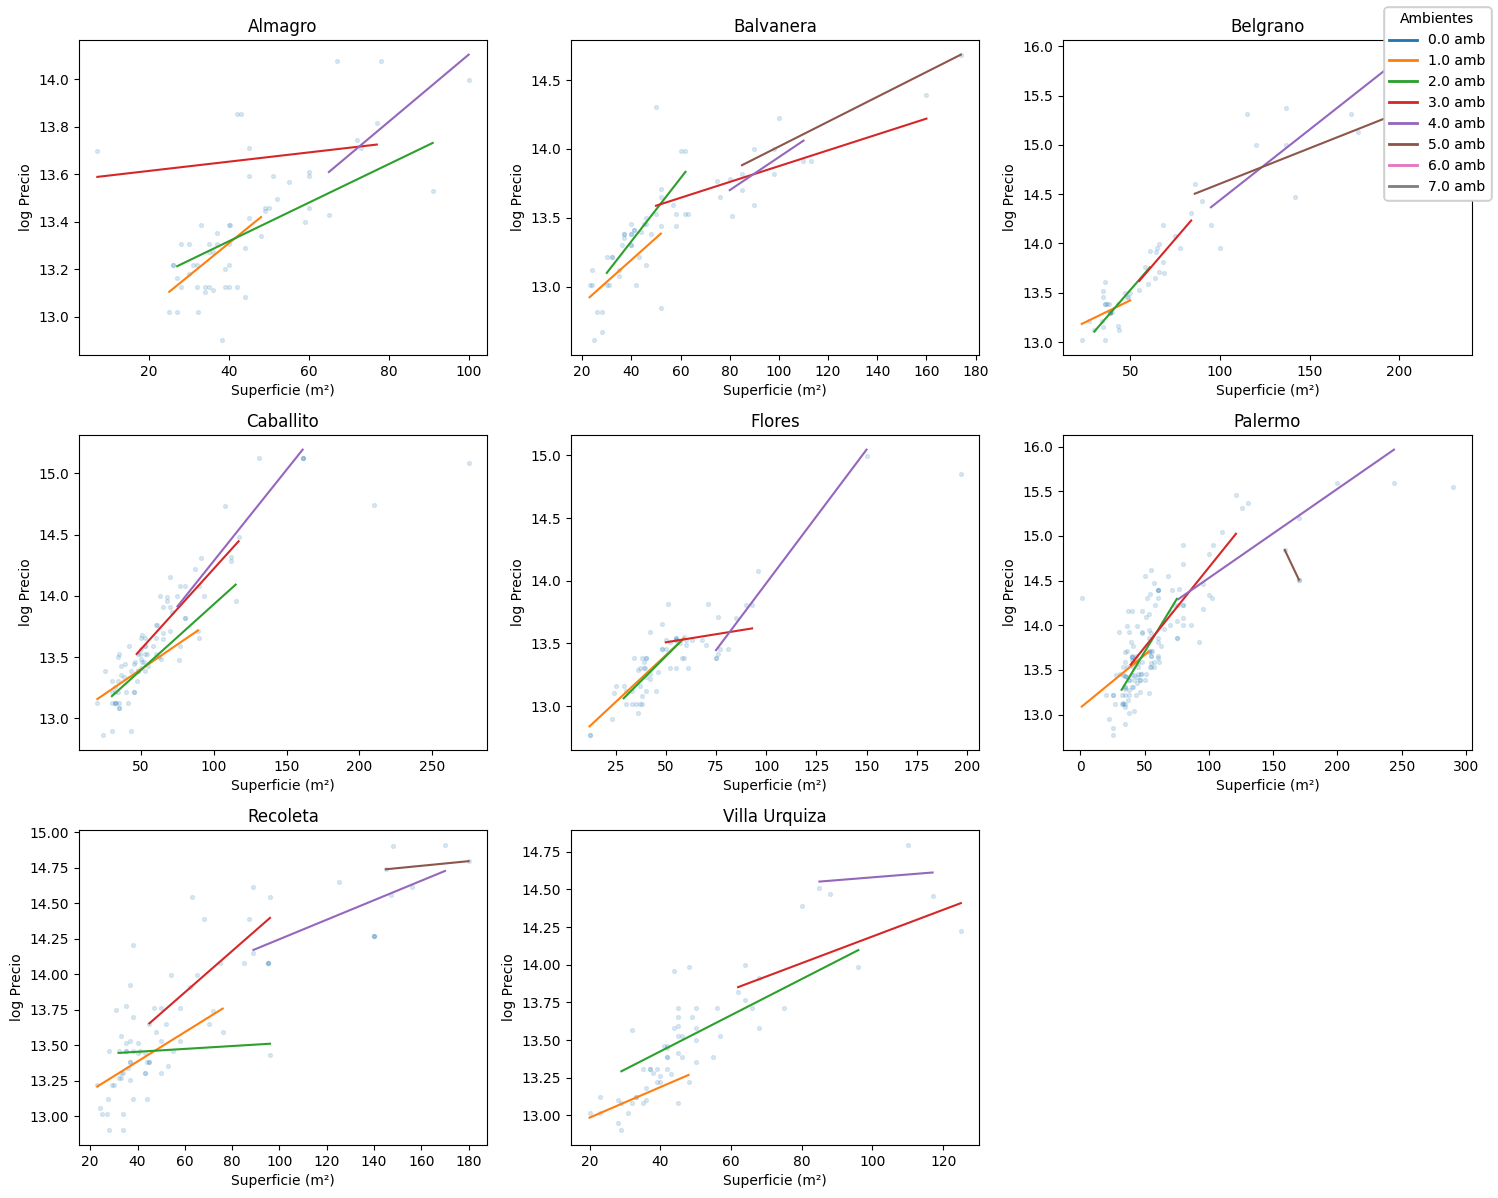

In [9]:
################## cambiar min obs ##################
min_obs = 50

barrios_con_observaciones = (
    gdf
    .groupby('barrio')
    .size()
    .loc[lambda s: s >= min_obs]
    .index
    .tolist()
)

n = len(barrios_con_observaciones)
ncols = 3
nrows = int(np.ceil(n / ncols))

import matplotlib.cm as cm
from matplotlib.lines import Line2D

ambientes = sorted(gdf['ambientes'].unique())
cmap = cm.get_cmap("tab10")

color_por_amb = {
    amb: cmap(i % cmap.N)
    for i, amb in enumerate(ambientes)
}

# Límites globales
xmin = gdf['area_m2_total'].min()
xmax = 400

ymin = gdf['log_precio'].min()
ymax = 2*1e6


fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for ax, barrio in zip(axes, barrios_con_observaciones):

    gdf_b = gdf[gdf['barrio'] == barrio]

    # ---- densidad de puntos ----
    ax.scatter(
        gdf_b['area_m2_total'],
        gdf_b['log_precio'],
        s=8,
        alpha=0.15
    )

    for amb in sorted(gdf_b['ambientes'].unique()):
        sub = gdf_b[gdf_b['ambientes'] == amb]

        X = sm.add_constant(sub['area_m2_total'])
        y = sub['log_precio']

        model = sm.OLS(y, X).fit()

        x_grid = np.linspace(
            sub['area_m2_total'].min(),
            sub['area_m2_total'].max(),
            100
        )

        y_hat = model.predict(
            sm.add_constant(x_grid)
        )

        ax.plot(
            x_grid,
            y_hat,
            color=color_por_amb[amb],
            label=f'{amb} amb'
        )



    ax.set_title(barrio)
    ax.set_xlabel('Superficie (m²)')
    ax.set_ylabel('log Precio')

    legend_elements = [
        Line2D(
            [0], [0],
            color=color_por_amb[amb],
            lw=2,
            label=f'{amb} amb'
        )
        for amb in ambientes
    ]

    fig.legend(
        handles=legend_elements,
        loc='upper right',
        title='Ambientes'
    )

for ax in axes[len(barrios_con_observaciones):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


Dependencia espacial del precio

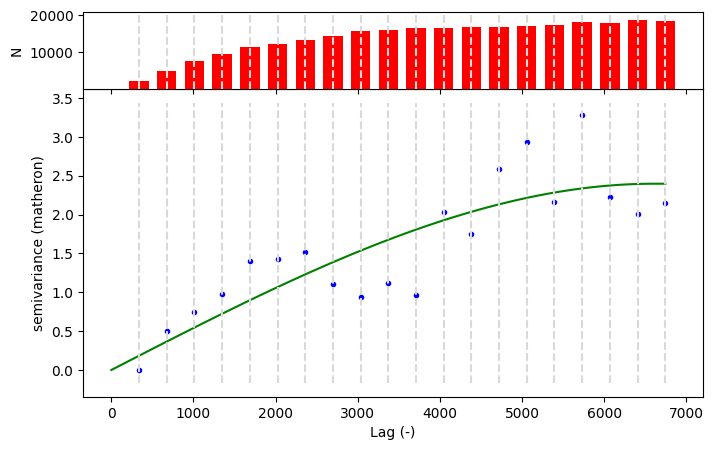

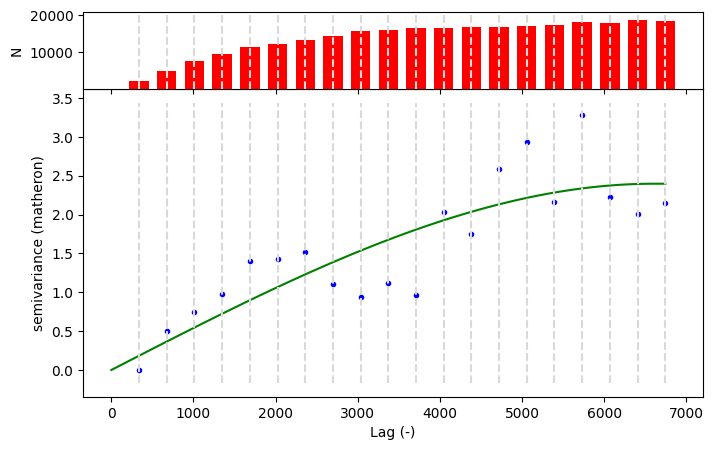

In [10]:


gdf = gdf.to_crs(epsg=3857)
coords = np.column_stack([
    gdf.geometry.x,
    gdf.geometry.y
])

values = gdf['precio'].values

V = Variogram(
    coords,
    values,
    model='spherical',   # o 'exponential', 'gaussian'
    n_lags=20,
    maxlag='median',     # o una distancia en metros
    normalize=False
)
V.plot()

# Formulamos y entrenamos modelo

hacemos GWR + kriging en residuos. 

Lueog hacemos un RF + Krigin en residuos

In [11]:
import os
import sys
sys.path.append(os.path.abspath("../models"))


import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from esda.moran import Moran_Local
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from patsy import dmatrices
from pykrige.rk import RegressionKriging
from statsmodels.robust.scale import mad
from libpysal.weights import Kernel
from models.gwrmodel import GWRModel
from models.rfrkModel import RegressionKrigingModel
from models.modelEvaluator import ModelEvaluator
from models.spatialOutlierDetector import SpatialOutlierDetector



In [12]:

gwrmodel = GWRModel()
rfrkmodel = RegressionKrigingModel()
features_gwr = [
    'area_m2_total',
    'area_m2_descubierta',
    'ambientes',
    'antiguedad',
    'expensas'
]

features_rfrk = [
    'area_m2_total',
    'area_m2_descubierta',
    'ambientes',
    'antiguedad',
    'expensas',
    'banos',
    'cocheras',
    'estado_num'
]

features_for_models = [features_gwr, features_rfrk]

response = 'log_precio'

models = [gwrmodel, rfrkmodel]
metrics = {}
residuals_models = {}

gdf = gdf.to_crs(epsg=3857)

gdf_train, gdf_test = train_test_split(
    gdf,
    test_size=0.1,
    random_state=42
)

coords_train = np.column_stack([gdf_train.geometry.x, gdf_train.geometry.y])
coords_test  = np.column_stack([gdf_test.geometry.x,  gdf_test.geometry.y])
coords_tot   = np.column_stack([gdf.geometry.x,   gdf.geometry.y])


evaluator = ModelEvaluator()
for i in range(len(models)):
    model  = models[i]
    features = features_for_models[i]
    X_train = gdf_train[features]
    Y_train = gdf_train[response].to_numpy().reshape(-1,1)
    X_test  = gdf_test[features]
    Y_test  = gdf_test[response].to_numpy().reshape(-1,1)
    X_tot   = gdf[features]
    Y_tot   = gdf[response].to_numpy().reshape(-1,1)

    #model.tune_hyperparameters(X_train, Y_train, coords_train,)
    model.fit(X_train, Y_train, coords_train)
    res_test = model.predict(X_test, coords_test)
    metrics[str(model.__class__.__name__)] = evaluator.evaluate(Y_test, res_test)

    model.fit(X_tot, Y_tot, coords_tot)
    residuals_models[str(model.__class__.__name__)] = Y_tot - model.predict(X_tot, coords_tot)
    


Finished learning regression model
Finished kriging residuals
Finished learning regression model
Finished kriging residuals


In [13]:
print(metrics)


{'GWRModel': {'rmse': 0.25037007506790565, 'mae': 0.18581988542458638, 'r2': 0.7533732706391154}, 'RegressionKrigingModel': {'rmse': 0.21672859715946383, 'mae': 0.15544909736518625, 'r2': 0.81519754160326}}


In [14]:
gwrmodel.summary()

Model type                                                         Gaussian
Number of observations:                                                1062
Number of covariates:                                                     6

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                            184.744
Log-likelihood:                                                    -578.226
AIC:                                                               1168.452
AICc:                                                              1170.559
BIC:                                                              -7173.368
R2:                                                                   0.538
Adj. R2:                                                              0.536

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

In [15]:
pd.Series(
    rfrkmodel.feature_importances_(),
    index=features_rfrk
).sort_values(ascending=False)

area_m2_total          0.290530
expensas               0.184495
banos                  0.125333
ambientes              0.125083
antiguedad             0.110329
estado_num             0.069180
area_m2_descubierta    0.052594
cocheras               0.042456
dtype: float64

Hacer el grafico de gwr por feature, quizá suavizar
Generar suavizado de precio por metro cudrado predecido para un departamento de 1 ambiente, 1 baño, etc. (una suerte de moda)
Generar Lisa/G* test y graficar
Encontrar outliers con z/t test robusto.

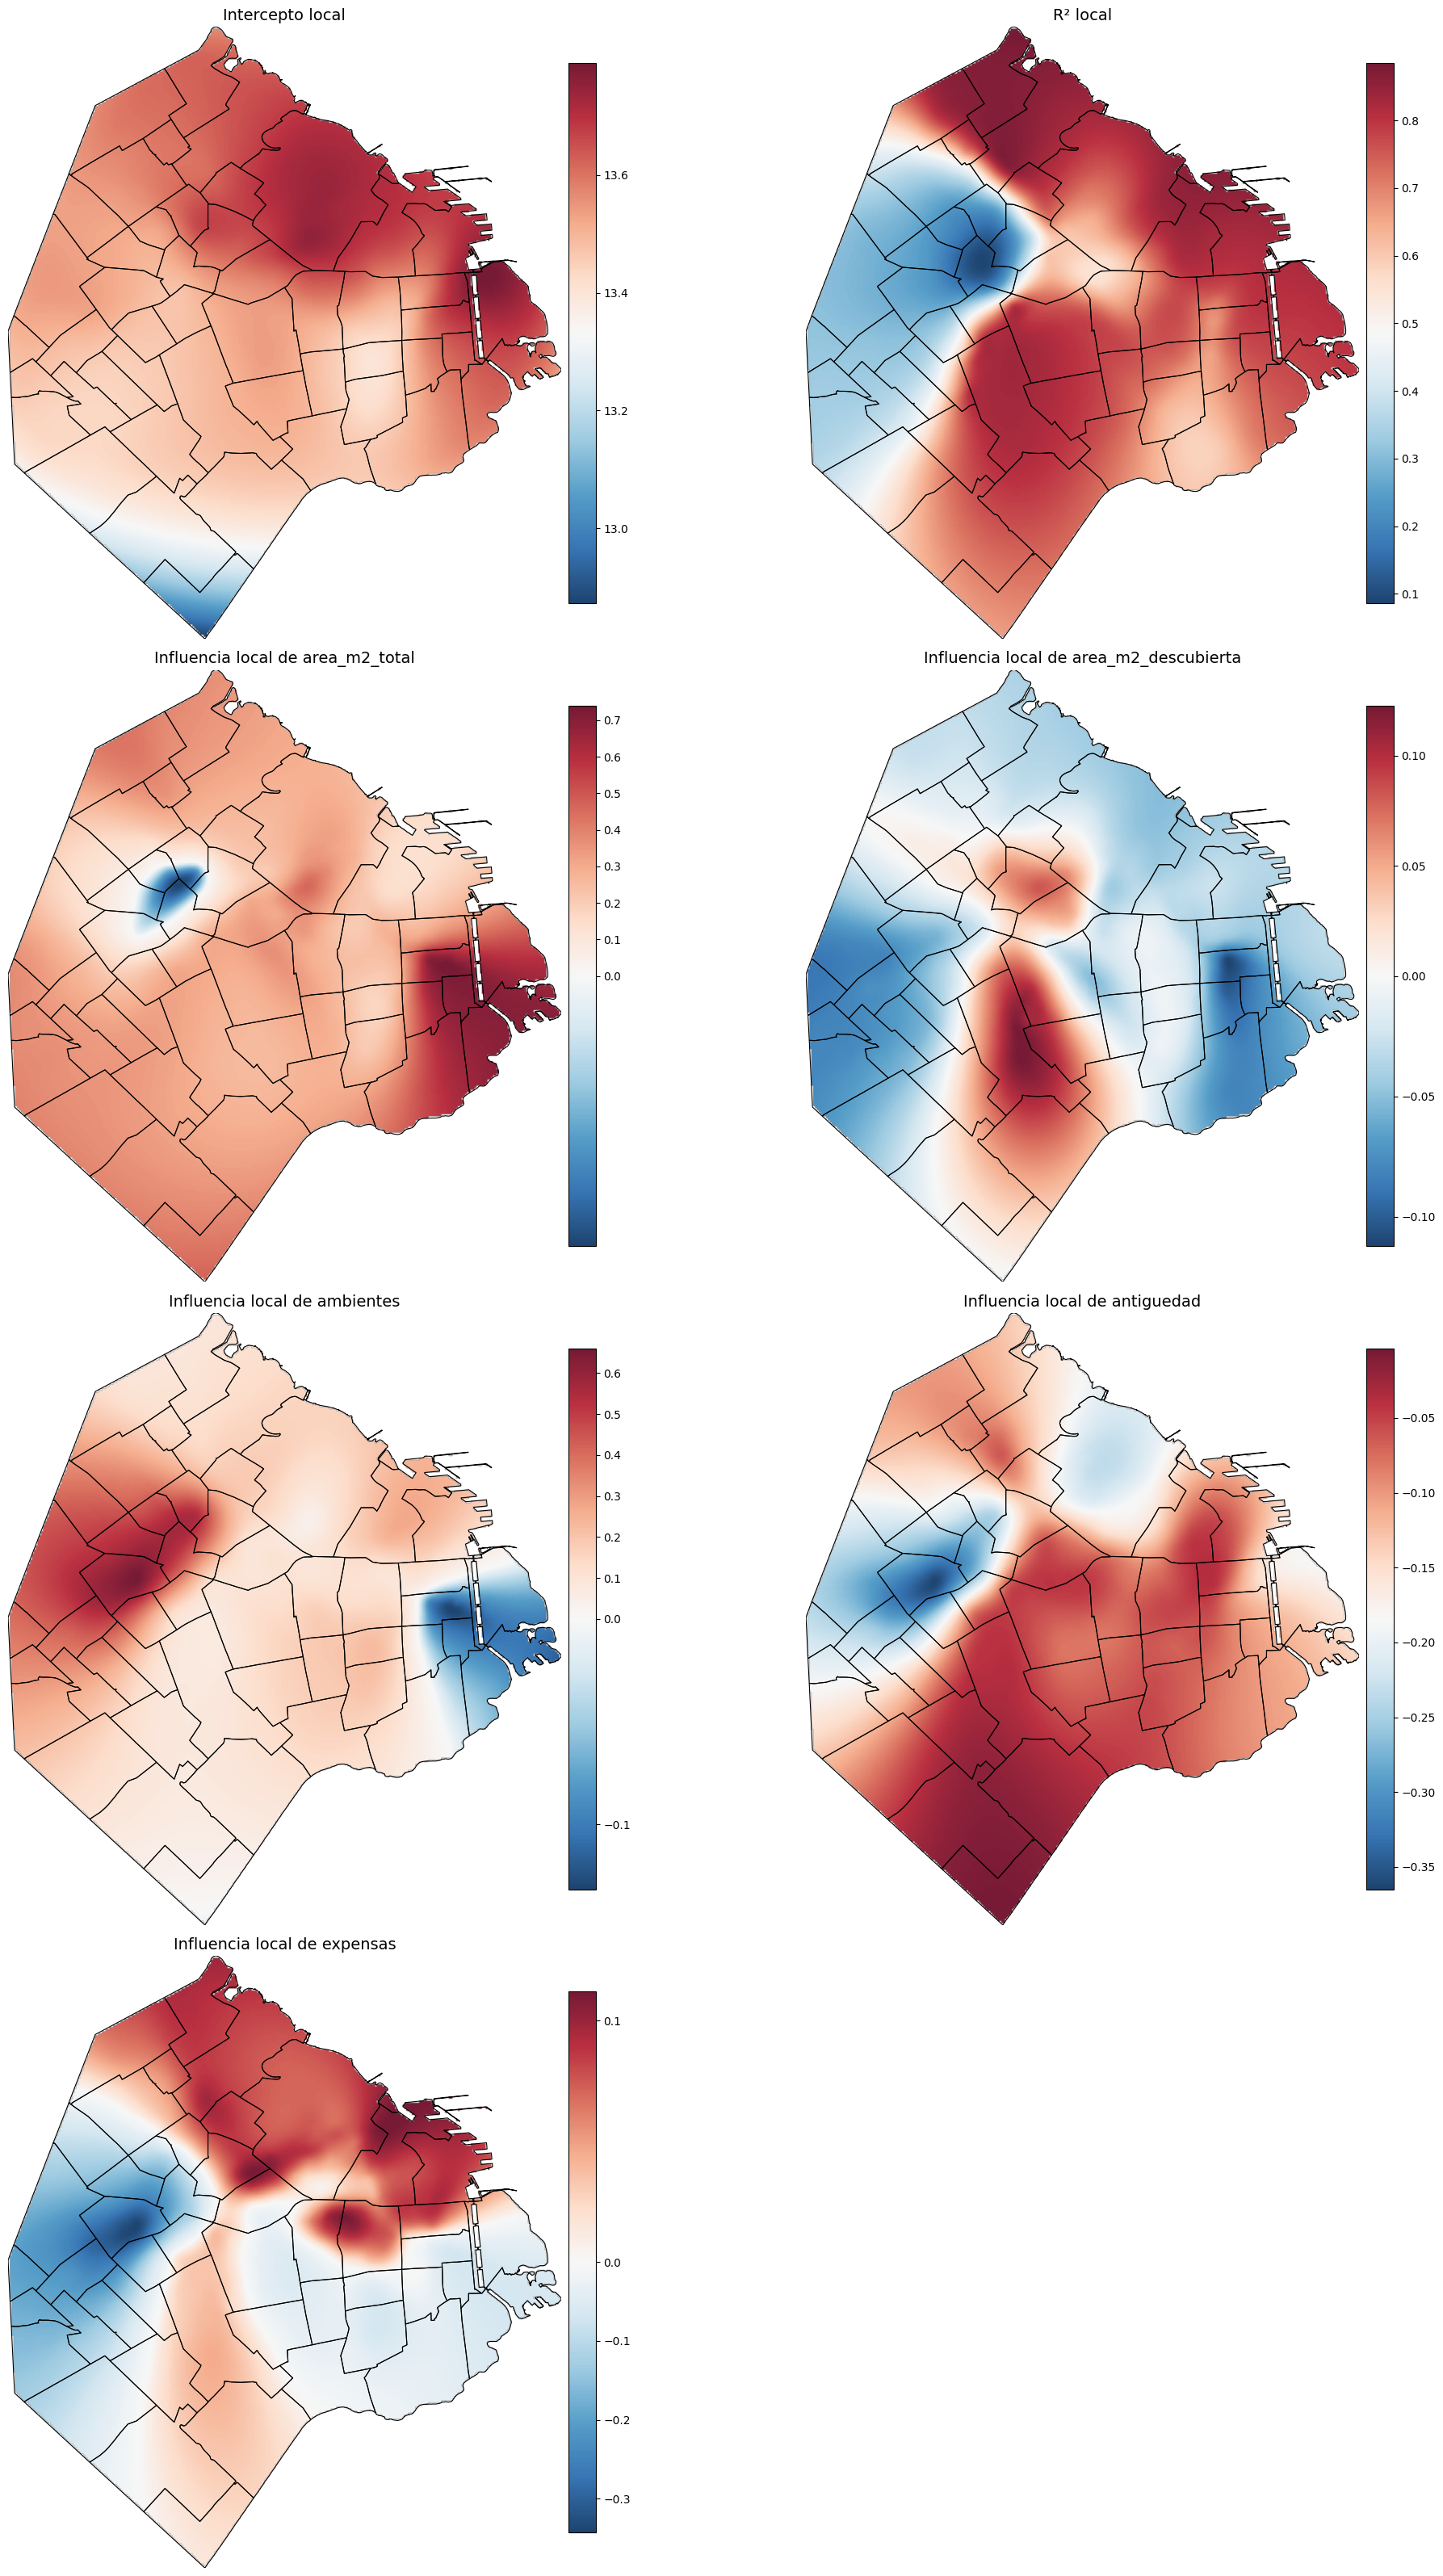

In [16]:
surfaces = gwrmodel.plot_gwr_surfaces(
    gdf=gdf.to_crs(epsg=3857),
    feature_names= features_gwr,
    barrios = barrios.to_crs(gdf.crs),
    grid_size=300,
    return_surfaces=True
)


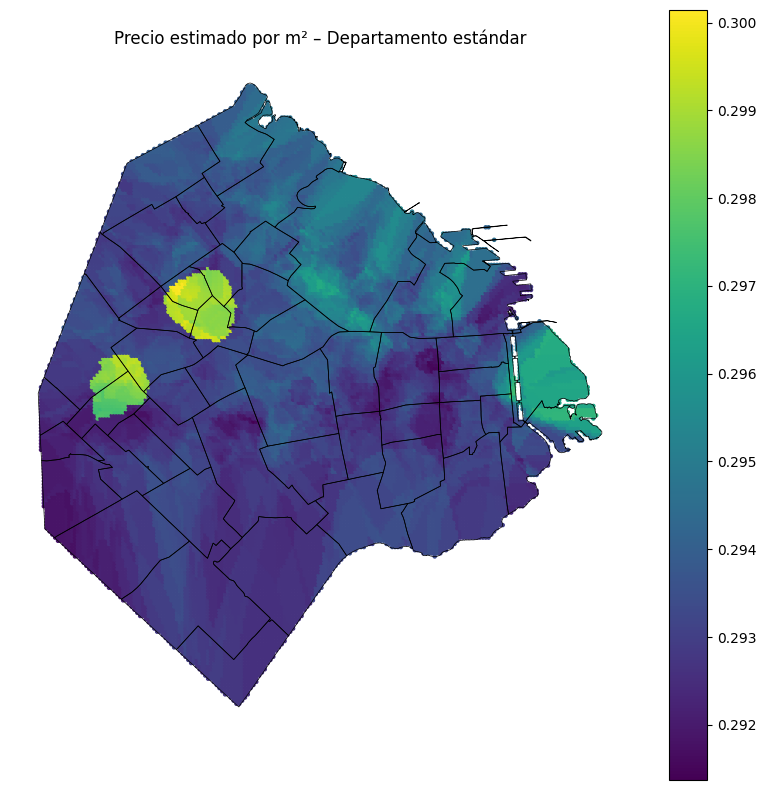

Precio por m^2 estimado para un departamento con las siguientes caracteristica:
  area_m2_total: 46.0
  area_m2_descubierta: 0.0
  ambientes: 2
  antiguedad: 30
  expensas: 150000.0
  banos: 1
  cocheras: 0
  estado_num: 5


In [17]:
#Tomamos precio estimado para un departamento lo más standard posible en una grilla de zonas
#Con esto, hacemos un mapa con la estimación del precio por m2 en función de la ubicación
barrios = gpd.read_file("barrios.geojson")
barrios = barrios.to_crs(gdf.crs)
caba_polygon = unary_union(barrios.geometry)

std_depto = {
    "area_m2_total": gdf["area_m2_total"].median(),
    "area_m2_descubierta": gdf["area_m2_descubierta"].median(),
    "ambientes": int(round(gdf["ambientes"].median())),
    "antiguedad": int(round(gdf["antiguedad"].median())),
    "expensas": gdf["expensas"].median(),
    "banos": int(round(gdf["banos"].median())),
    "cocheras": int(round(gdf["cocheras"].median())),
    "estado_num": int(round(gdf["estado_num"].median())),
}
xmin, ymin, xmax, ymax = caba_polygon.bounds
grid_size = 200

xs = np.linspace(xmin, xmax, grid_size)
ys = np.linspace(ymin, ymax, grid_size)

xx, yy = np.meshgrid(xs, ys)
coords_grid = np.column_stack([xx.ravel(), yy.ravel()])
gdf_grid = gpd.GeoDataFrame(
    geometry=[Point(xy) for xy in coords_grid],
    crs=gdf.crs
)
gdf_grid = gdf_grid[gdf_grid.within(caba_polygon)]
coords_grid = np.array([(p.x, p.y) for p in gdf_grid.geometry])
X_std_grid = pd.DataFrame(
    [std_depto] * len(coords_grid),
    columns=std_depto.keys()
)
y_pred = rfrkmodel.predict(
    X_std_grid.values,
    coords_grid
)
gdf_grid["precio_m2"] = y_pred / std_depto["area_m2_total"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

gdf_grid.plot(
    column="precio_m2",
    ax=ax,
    cmap="viridis",
    markersize=5,
    legend=True
)

barrios.boundary.plot(ax=ax, color="black", linewidth=0.5)

ax.set_title("Precio estimado por m² – Departamento estándar")
ax.axis("off")

plt.show()

print("Precio por m^2 estimado para un departamento con las siguientes caracteristica:")
for k, v in std_depto.items():
    print(f"  {k}: {v}")

In [26]:
spatial_outlier_detector = SpatialOutlierDetector()
w = Kernel(
    coords,
    function="gaussian",  # o "gaussian"
    fixed=False           # ← CLAVE: adaptativo
)
outliers = spatial_outlier_detector.z_test_spatial_outliers(
    X = gdf[features_rfrk].values,
    y = residuals_models['RegressionKrigingModel'],
    coords = coords_tot,
    w=w
)

gdf.iloc[outliers['outlier_idx']]
gdf.iloc[outliers['outlier_idx']].to_csv("output/alquiler/outliers_lisa_rfrk_ztest.csv", index=False)

 There are 73 disconnected components.
